In [6]:
import torch
from pathlib import Path
from PIL import Image
import random
import os
import numpy as np


In [7]:
from ultralytics import YOLO

In [4]:
random_seed = 42
batch_size = 16

In [9]:
data_dir = Path("../data/TXL-PBC")
images_dir = data_dir / "images"
train_images_dir = data_dir / "images" / "train"

1260
Image shape: (575, 575, 3)


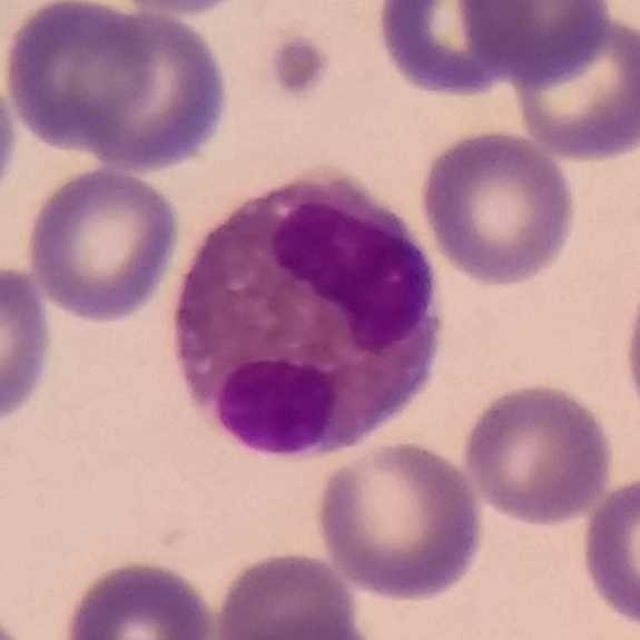

In [63]:
img_paths = list(images_dir.glob("*/*.png"))
print(len(img_paths))
sample_img = img_paths[random.randint(0, len(img_paths) - 1)]
img = Image.open(sample_img)
print(f"Image shape: {np.array(img).shape}")
img.resize(size=(640, 640))

In [64]:
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [65]:
walk_through_dir(images_dir)

There are 3 directories and 0 images in '..\data\TXL-PBC\images'.
There are 0 directories and 126 images in '..\data\TXL-PBC\images\test'.
There are 0 directories and 882 images in '..\data\TXL-PBC\images\train'.
There are 0 directories and 252 images in '..\data\TXL-PBC\images\val'.


In [66]:
model = YOLO(model="yolo26s.pt", task="detect")


In [ ]:
results = model.train(data="data.yaml", epochs=20, imgsz=640)